# Heart Disease Dataset

The Heart Disease dataset is a healthcare dataset used for predicting whether a patient is likely to have heart disease.

Target Variable:
- 0 → No Heart Disease
- 1 → Heart Disease Present

---

# Column Descriptions

| Column | Description |
|--------|-------------|
| age | Age of the patient |
| sex | Gender of the patient (1 = Male, 0 = Female) |
| cp | Chest pain type |
| trestbps | Resting blood pressure |
| chol | Serum cholesterol level |
| fbs | Fasting blood sugar level |
| restecg | Resting electrocardiographic results |
| thalach | Maximum heart rate achieved |
| exang | Exercise induced angina |
| oldpeak | ST depression induced by exercise |
| slope | Slope of the peak exercise ST segment |
| ca | Number of major vessels colored by fluoroscopy |
| thal | Thalassemia defect type |
| target | Presence of heart disease |

---

# Feature Categories

## Numerical Features
- age
- trestbps
- chol
- thalach
- oldpeak

## Categorical Features
- sex
- cp
- fbs
- restecg
- exang
- slope
- ca
- thal

## Target Feature
- target

---



In [377]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import (
    DecisionTreeRegressor,
    DecisionTreeClassifier
)
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Dataset Column Description

| Column | Description |
|--------|-------------|
| **age** | Age of the individual |
| **sex** | Gender of the patient (`0 = Female`, `1 = Male`) |
| **chest pain type (cp)** | Type of chest pain experienced (`0–3`) |
| **resting blood pressure (trestbps)** | Resting blood pressure measured in mm Hg |
| **serum cholesterol (chol)** | Cholesterol level measured in mg/dl |
| **fasting blood sugar (fbs)** | Whether fasting blood sugar is greater than 120 mg/dl (`1 = True`, `0 = False`) |
| **resting electrocardiographic results (restecg)** | ECG test results (`0–2`) |
| **maximum heart rate achieved (thalach)** | Highest heart rate achieved during exercise |
| **exercise induced angina (exang)** | Exercise-induced chest pain (`1 = Yes`, `0 = No`) |
| **oldpeak** | ST depression induced by exercise relative to rest |
| **slope** | Slope of the peak exercise ST segment |
| **number of major vessels (ca)** | Number of major blood vessels colored by fluoroscopy |
| **thal** | Type of thalassemia defect |
| **target** | Presence of heart disease (`1 = Yes`, `0 = No`) |

In [378]:
df = pd.read_csv('/content/heart_disease.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [379]:
print(df.isna().sum()) #no null values

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [380]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [381]:
df.info() #observed that all of the rows are numeric thus no need of encoding categorical values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [382]:
df.shape

(1025, 14)

In [383]:
df.duplicated().sum()

np.int64(723)

In [384]:
duplicates = df[df.duplicated()]

print(duplicates) #there are a lot of duplicated rows of around 700 so dropped it

      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
15     34    0   1       118   210    0        1      192      0      0.7   
31     50    0   1       120   244    0        1      162      0      1.1   
43     46    1   0       120   249    0        0      144      0      0.8   
55     55    1   0       140   217    0        1      111      1      5.6   
61     66    0   2       146   278    0        0      152      0      0.0   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
15        2   0     2       1  
31        2

In [385]:
df = df.drop_duplicates()

In [386]:
df.shape

(302, 14)

#Data cleaning-DONE
Data cleaning has been done by this stage, The dataset was observed to have already been cleaned of any null values or labels. The Categorical Values has already been turned into numerical values thus the only step required was the elimination of duplicate rows that were of 723, reducing the size to 302 unique rows with 14 cols

#UNIVARIATE ANALYSIS

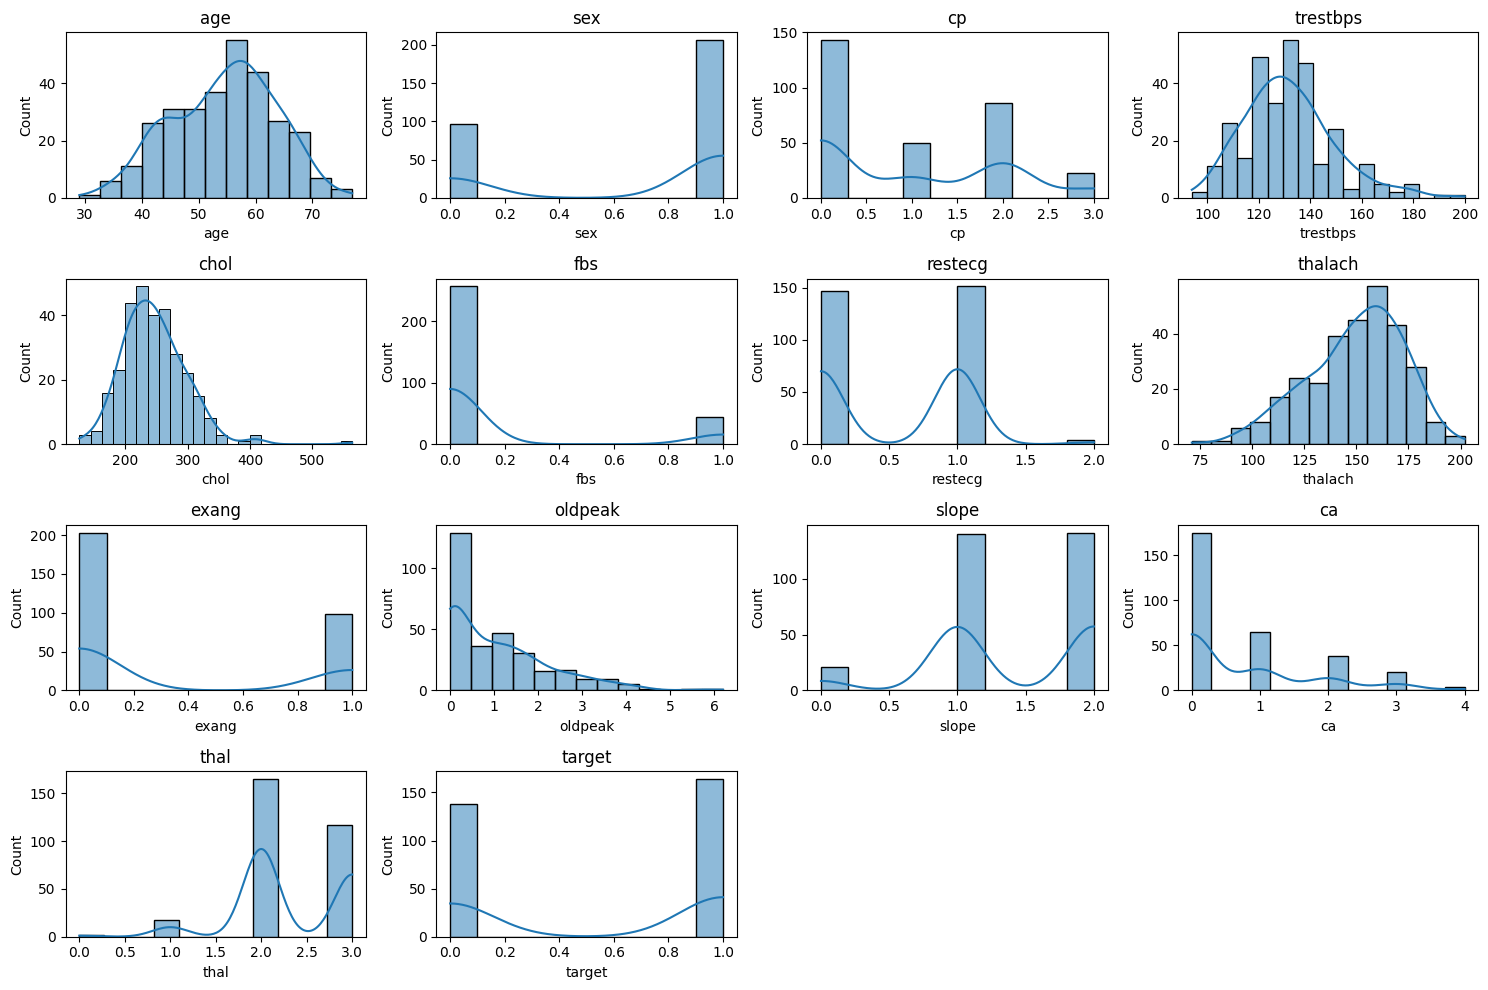

In [387]:
numerical_cols = df.select_dtypes(include=np.number).columns

# Create subplot grid
fig, axes = plt.subplots(4, 4, figsize=(15,10))

# Flatten axes for looping
axes = axes.flatten()

# Plot histograms with KDE
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

# Remove unused empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#Results of Univariate analysis:


1.   trestbps has a slight right skew
2.   chol has a clear right skew


1.   thalach has a slight left skew
2.   oldpeak has a strong right skew hinting at outliers


1.   CA also has a outlier



1.   Males dominate this analysis
2.   thal=0 looks like a placeholder for null values given how low it is (<1%)










#Bivariate Analysis
##Regression Features

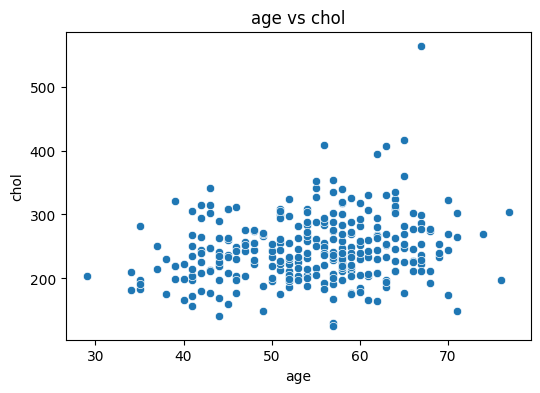

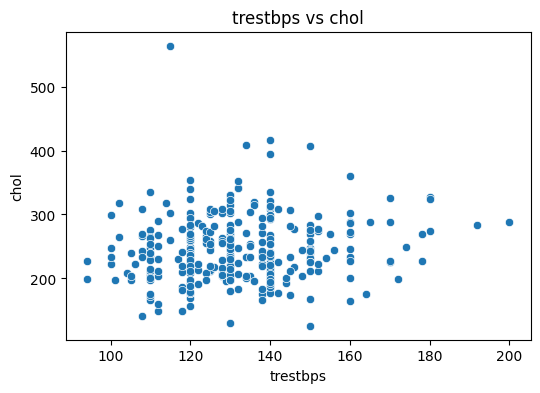

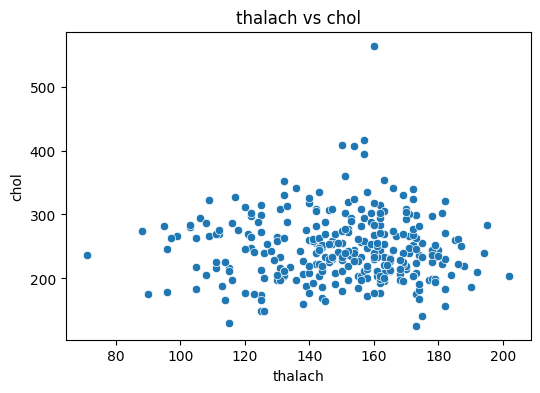

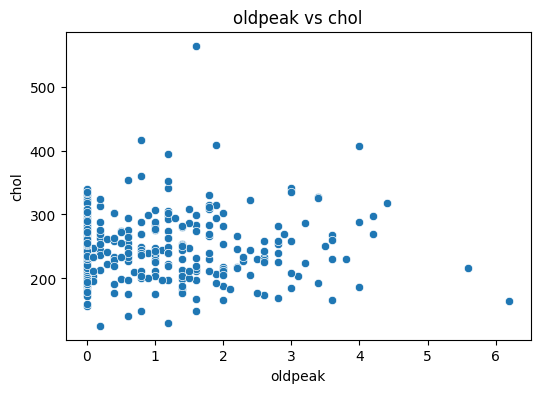

In [388]:
num_cols = ['age', 'trestbps', 'thalach', 'oldpeak']
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df['chol'])
    plt.title(f'{col} vs chol')
    plt.xlabel(col)
    plt.ylabel('chol')
    plt.show()

All of the graphs indicate that the relationship between different features and chol is not uniform and cannot be measured


In [389]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang',
            'slope', 'ca', 'thal']

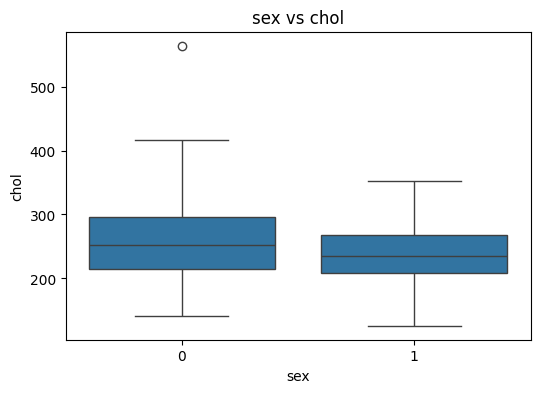

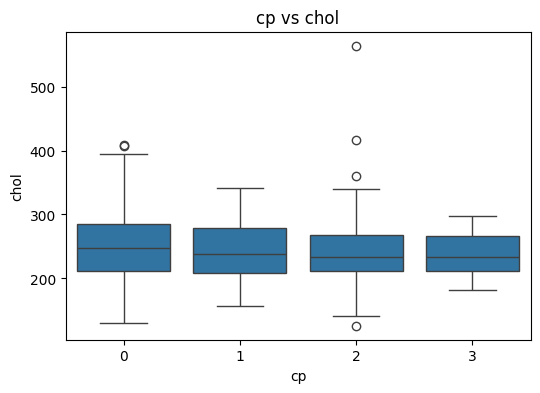

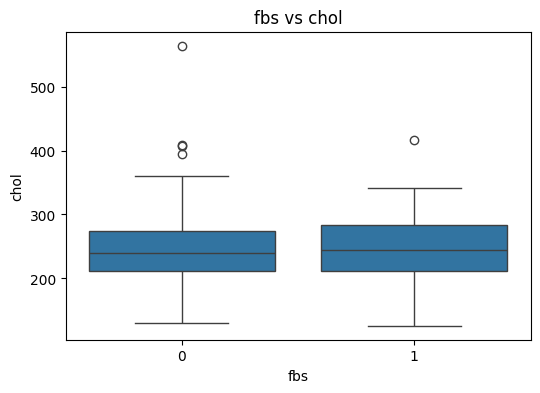

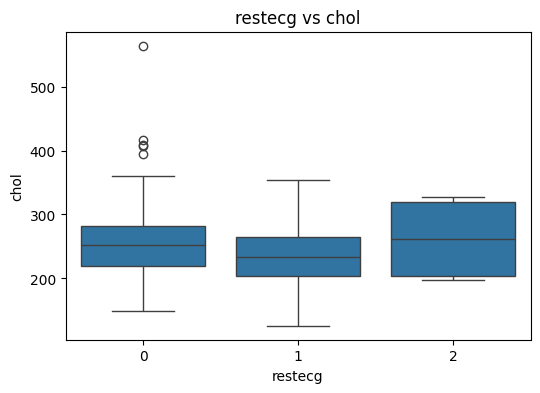

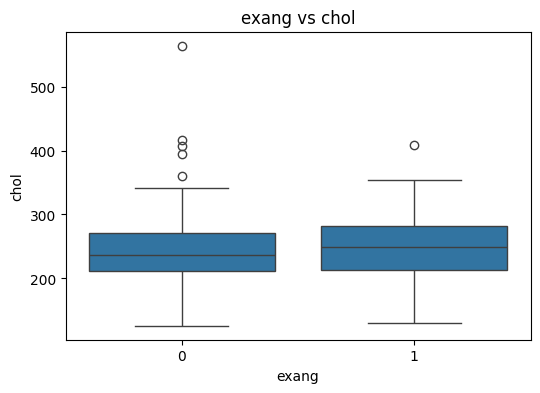

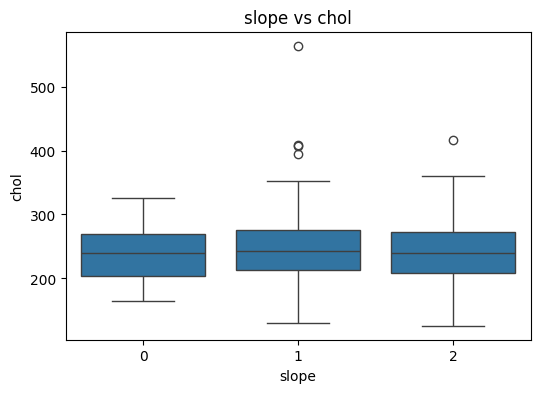

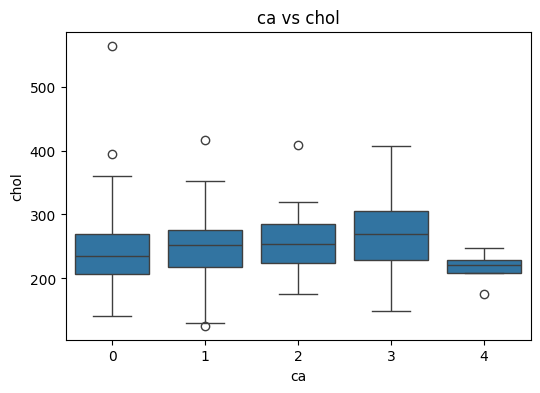

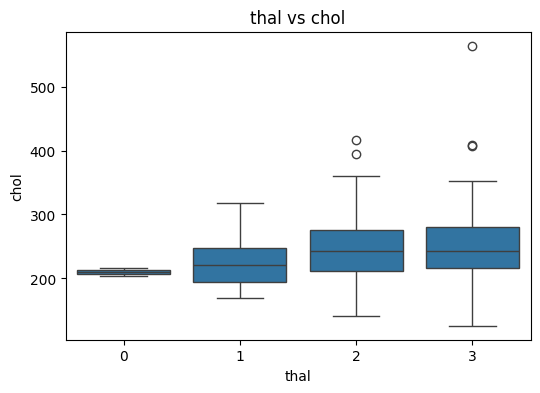

In [390]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], y=df['chol'])
    plt.title(f'{col} vs chol')
    plt.show()

Observed that outliers exists in some of the classes

there exists some relationship between the restecg=2 and the chol

#Bivariate for classification
##Classification Features


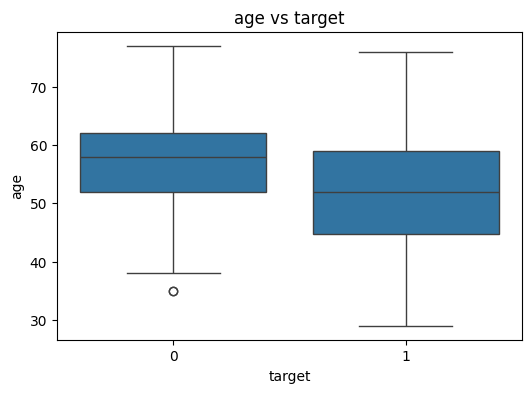

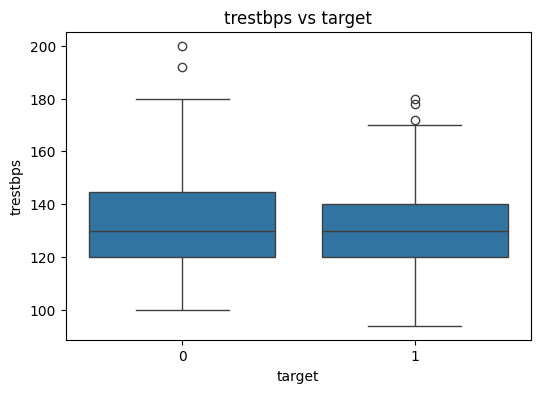

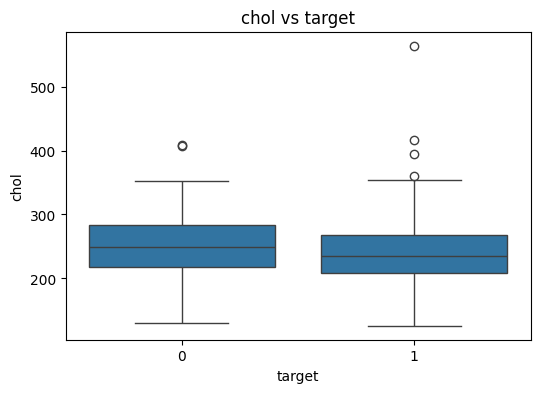

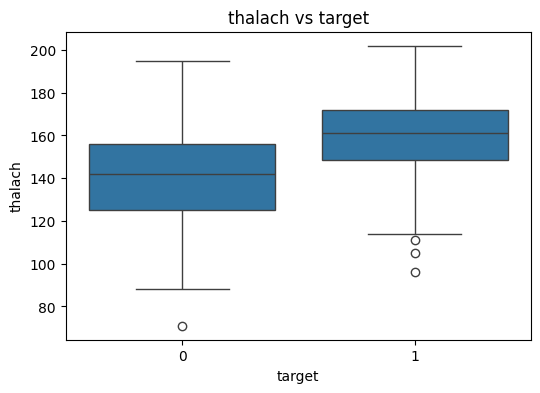

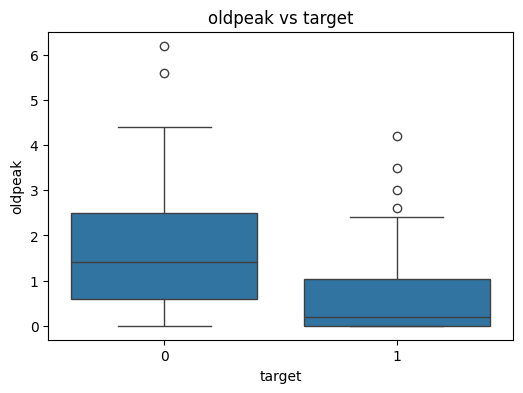

In [391]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='target', y=col, data=df)
    plt.title(f'{col} vs target')
    plt.show()

Old peak vs target seems to have a strong relationship the data has a larger spread with differnet medians

Same case for thalach

rest of them have similiar medians and spread so are weaker for regression cases for target


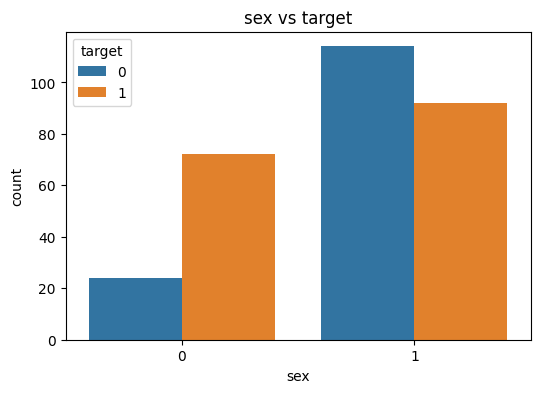

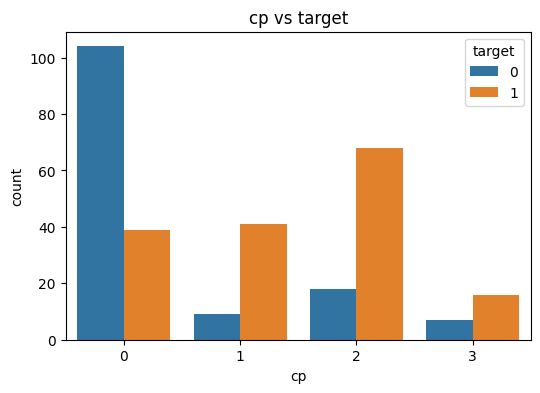

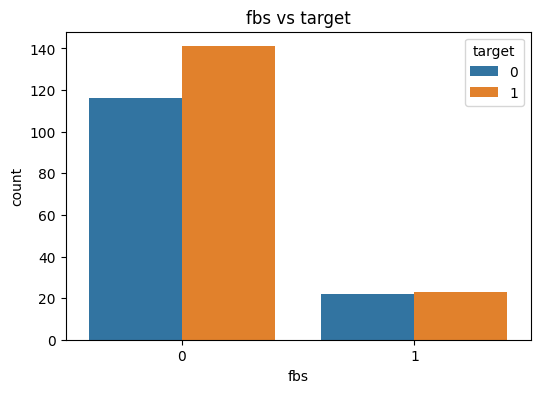

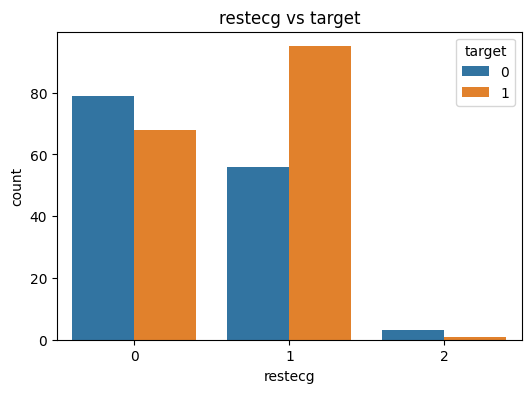

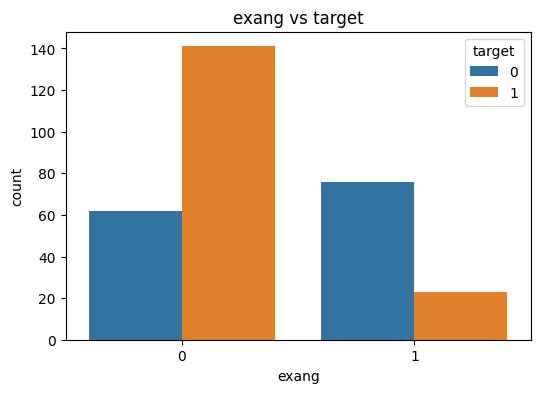

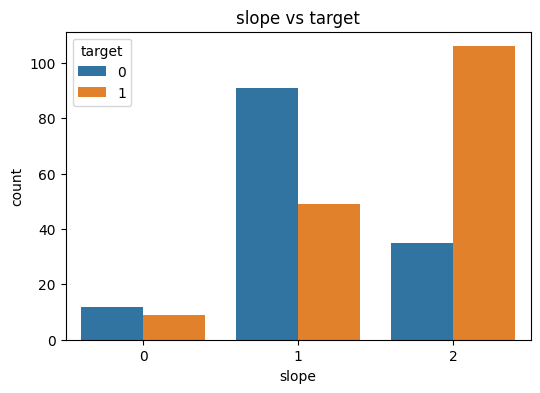

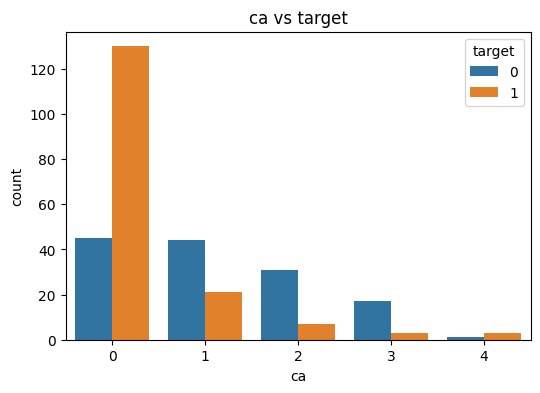

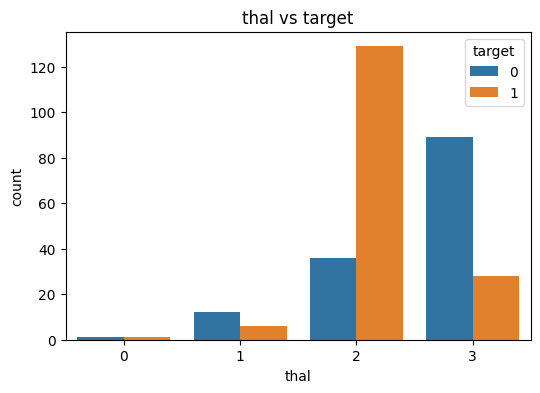

In [392]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang',
            'slope', 'ca', 'thal']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='target', data=df)
    plt.title(f'{col} vs target')
    plt.show()

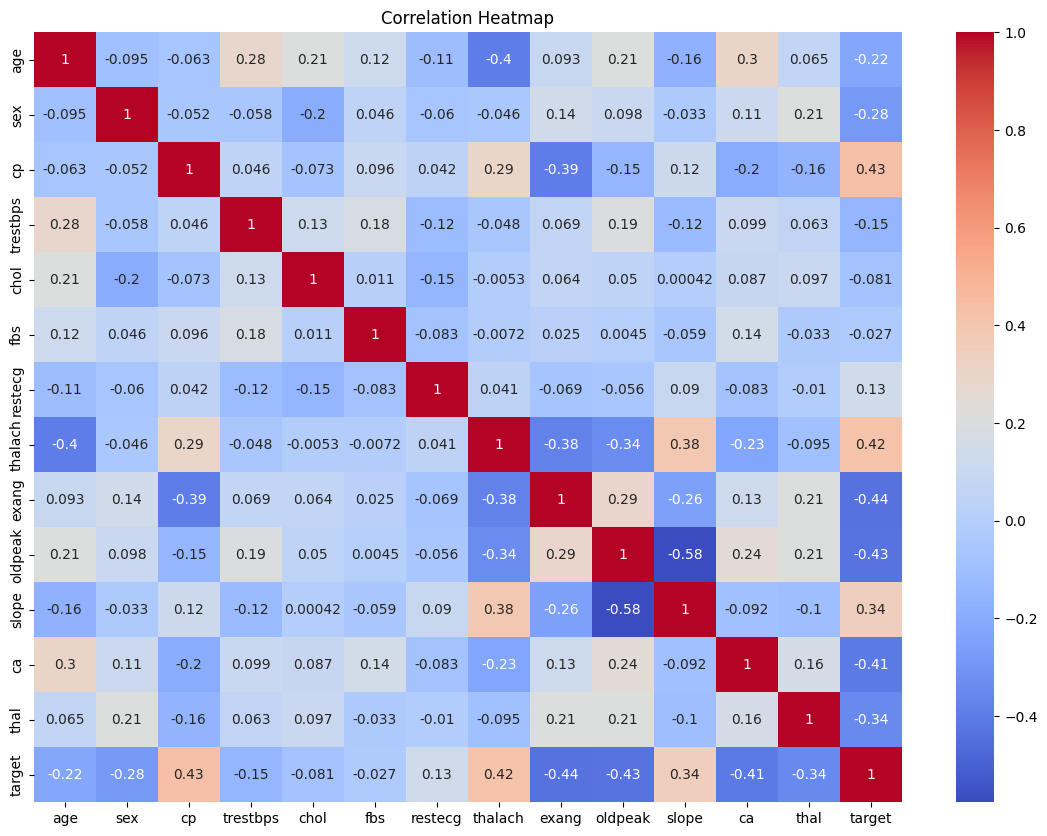

In [393]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()



*   Red= +ve correlation
*   Blue= -ve correlation

*   No color/white/grey= Weak correlation

#Observation from the heatmap(Target variable)



1.   Chest pain(cp) has a moderate correlation with our target with a value of 0.43
2.   Thalach has a moderate correlation with target with value of 0.42


1.   Exang has a moderate negative correlation of -.044

2.   oldpeak has a moderate negative correlation of -0.43


1.   ca has a moderate negative correlation of -0.41
2.   thalach has a moderate negative correlation of -034

#Observation from the heatmap(chol variable)

the chol variable which was selected for linear regression has no correlation with any of the given features of the dataset, Making Linear regression not able to be applied to find out value of chol given features




*   Thus decided to go forward using Random Forest/ Decision trees to find out the chol's  values








In [394]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg',
            'exang', 'slope', 'ca', 'thal', 'target']

for col in cat_cols:

    print("\nColumn:", col)
    print(df[col].value_counts())

    #sns.countplot(x=col, data=df)
    #plt.show()


Column: sex
sex
1    206
0     96
Name: count, dtype: int64

Column: cp
cp
0    143
2     86
1     50
3     23
Name: count, dtype: int64

Column: fbs
fbs
0    257
1     45
Name: count, dtype: int64

Column: restecg
restecg
1    151
0    147
2      4
Name: count, dtype: int64

Column: exang
exang
0    203
1     99
Name: count, dtype: int64

Column: slope
slope
2    141
1    140
0     21
Name: count, dtype: int64

Column: ca
ca
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64

Column: thal
thal
2    165
3    117
1     18
0      2
Name: count, dtype: int64

Column: target
target
1    164
0    138
Name: count, dtype: int64


In [395]:
df.skew(numeric_only=True)

,0
age,-0.203743
sex,-0.786120
cp,0.493022
trestbps,0.716541
chol,1.147332
fbs,1.981201
restecg,0.169467
thalach,-0.532671
exang,0.737281
oldpeak,1.266173


In [396]:
import numpy as np

outlier_cols = ['trestbps', 'chol', 'thalach', 'oldpeak']

for col in outlier_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Capping
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

print("Outlier capping completed.")

Outlier capping completed.


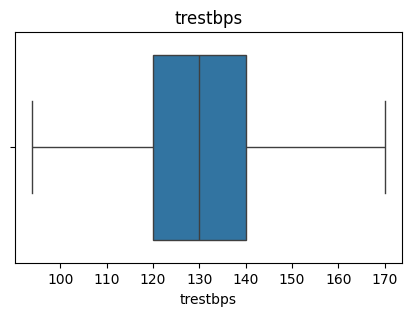

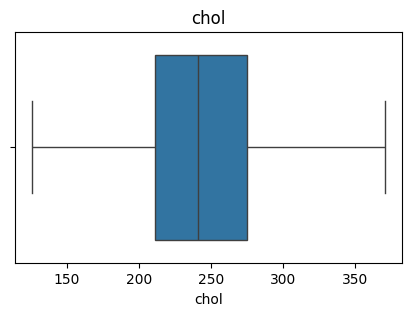

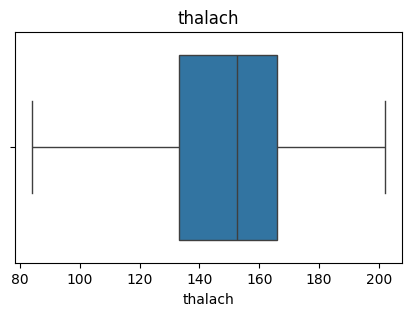

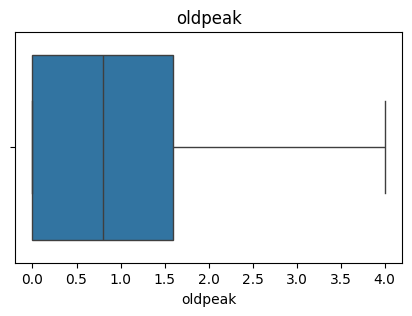

In [397]:
for col in outlier_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

#Outlier handling

capped the outliers in numerical cols using the IQR method with capping. The boxplots of the cols now don't have outliers that massively skew the matrix

In [398]:
df['thal'].value_counts()

,count
thal,
2,165
3,117
1,18
0,2


In [399]:
df = df[df['thal'] != 0] #removed thal=0 as the value is around 0.66% so most likely a placeholder or a fault

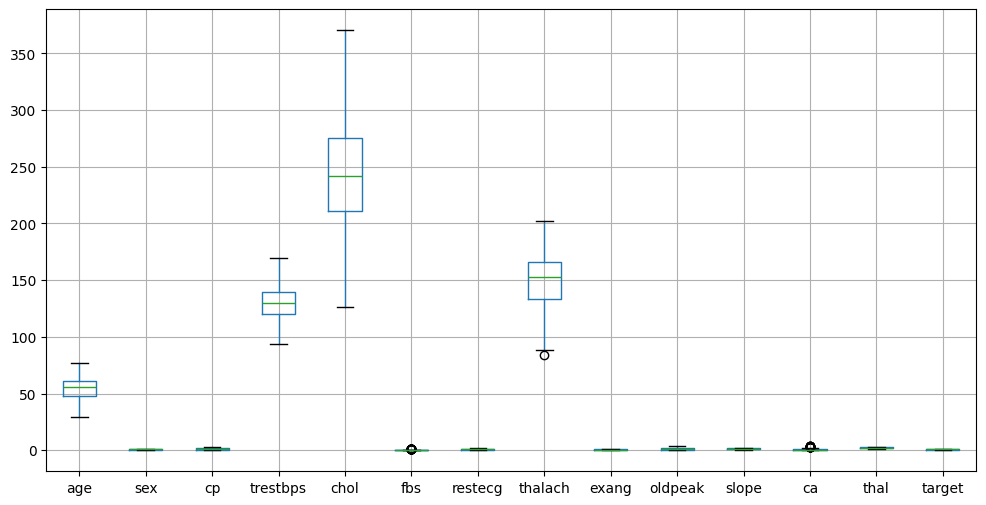

In [400]:
df.boxplot(figsize=(12,6))

plt.show()

In [401]:
X_reg = df.drop('chol', axis=1)
y_reg = df['chol']

print(X_reg.shape)
print(y_reg.shape)

(300, 13)
(300,)


In [402]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print(X_train_reg.shape)
print(X_test_reg.shape)

(240, 13)
(60, 13)


In [403]:
scaler_reg = RobustScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

In [404]:
linear_model = LinearRegression()

linear_model.fit(X_train_reg_scaled, y_train_reg)

LinearRegression()

In [405]:
y_pred_linear = linear_model.predict(X_test_reg_scaled)

In [406]:
print("MAE:", mean_absolute_error(y_test_reg, y_pred_linear))

print("MSE:", mean_squared_error(y_test_reg, y_pred_linear))

print("R2 Score:", r2_score(y_test_reg, y_pred_linear))

MAE: 38.42009779363918
MSE: 2307.04550426244
R2 Score: -0.08200799050058882


## Observation of Linear Regression

> Linear Regression produced high prediction errors with an MAE of 38.42 and MSE of 2307.05. The negative R² score (-0.082) indicates that the model failed to capture a meaningful linear relationship between the features and cholesterol levels.


In [407]:
poly_model = make_pipeline(
    PolynomialFeatures(degree=2),
    RobustScaler(),
    LinearRegression()
)
poly_model.fit(X_train_reg, y_train_reg)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                ('robustscaler', RobustScaler()),
                ('linearregression', LinearRegression())])

In [408]:
y_pred_poly = poly_model.predict(X_test_reg)

In [409]:
print("MAE:", mean_absolute_error(y_test_reg, y_pred_poly))

print("MSE:", mean_squared_error(y_test_reg, y_pred_poly))

print("R2 Score:", r2_score(y_test_reg, y_pred_poly))

MAE: 51.16787140391146
MSE: 4911.477058250233
R2 Score: -1.3034905086911328


## Observation of Polynomial Regression

> Polynomial Regression produced higher prediction errors with an MAE of 51.17 and MSE of 4911.48. The R² score of -1.303 indicates severe overfitting and poor generalization, showing that increasing model complexity did not improve cholesterol prediction.


In [410]:
dt_reg = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

dt_reg.fit(X_train_reg, y_train_reg)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [411]:
y_pred_dt = dt_reg.predict(X_test_reg)

In [412]:
print("MAE:", mean_absolute_error(y_test_reg, y_pred_dt))

print("MSE:", mean_squared_error(y_test_reg, y_pred_dt))

print("R2 Score:", r2_score(y_test_reg, y_pred_dt))

MAE: 42.99747139764996
MSE: 3072.0486810361504
R2 Score: -0.4407956903956185


## Observation of Decision Tree Regression

> Decision Tree Regression produced high prediction errors with an MAE of 43.00 and MSE of 3072.05. The negative R² score (-0.441) indicates poor generalization and weak predictive capability for cholesterol values.


In [413]:
rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=5
)

rf_reg.fit(X_train_reg, y_train_reg)

RandomForestRegressor(max_depth=5, random_state=42)

In [414]:
y_pred_rf = rf_reg.predict(X_test_reg)

In [415]:
print("MAE:", mean_absolute_error(y_test_reg, y_pred_rf))

print("MSE:", mean_squared_error(y_test_reg, y_pred_rf))

print("R2 Score:", r2_score(y_test_reg, y_pred_rf))

MAE: 37.89357584873018
MSE: 2233.155628578899
R2 Score: -0.04735352193506914


## Observation of Random Forest Regression

> Random Forest Regression produced lower prediction errors compared to the other regression models, with an MAE of 37.89 and MSE of 2233.16. However, the negative R² score (-0.047) indicates that the model still failed to predict cholesterol values effectively due to weak relationships between the features and the target variable.


In [416]:
X = df.drop('target', axis=1)
y = df['target']

print(X.shape)
print(y.shape)

(300, 13)
(300,)


In [417]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(240, 13)
(60, 13)


In [418]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [419]:
log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [420]:
y_pred_log = log_model.predict(X_test_scaled)

In [421]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))

print("Precision:", precision_score(y_test, y_pred_log))

print("Recall:", recall_score(y_test, y_pred_log))

print("F1-Score:", f1_score(y_test, y_pred_log))

Accuracy: 0.8
Precision: 0.7272727272727273
Recall: 0.8888888888888888
F1-Score: 0.8


## Observation of Logistic Regression

> Logistic Regression achieved an accuracy of 80%, with a precision of 72.73%, recall of 88.89%, and F1-score of 0.80. The model showed good overall classification performance and was effective at identifying heart disease cases.


In [422]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [423]:
y_pred_knn = knn_model.predict(X_test_scaled)

In [424]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

print("Precision:", precision_score(y_test, y_pred_knn))

print("Recall:", recall_score(y_test, y_pred_knn))

print("F1-Score:", f1_score(y_test, y_pred_knn))

Accuracy: 0.7833333333333333
Precision: 0.6944444444444444
Recall: 0.9259259259259259
F1-Score: 0.7936507936507936


## Observation of KNN Classification

> KNN Classification achieved an accuracy of 78.33%, with a precision of 69.44%, recall of 92.59%, and F1-score of 0.79. The model showed strong recall, indicating effective detection of heart disease cases, but produced more false positives compared to Logistic Regression.


In [425]:
nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

GaussianNB()

In [426]:
y_pred_nb = nb_model.predict(X_test_scaled)

In [427]:
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

print("Precision:", precision_score(y_test, y_pred_nb))

print("Recall:", recall_score(y_test, y_pred_nb))

print("F1-Score:", f1_score(y_test, y_pred_nb))

Accuracy: 0.7833333333333333
Precision: 0.75
Recall: 0.7777777777777778
F1-Score: 0.7636363636363637


## Observation of Naive Bayes Classification

> Naive Bayes Classification achieved an accuracy of 78.33%, with a precision of 75.00%, recall of 77.78%, and F1-score of 0.76. The model showed balanced classification performance with moderate precision and recall.


In [428]:
svm_model = SVC()

svm_model.fit(X_train_scaled, y_train)

SVC()

In [429]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [430]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print("Precision:", precision_score(y_test, y_pred_svm))

print("Recall:", recall_score(y_test, y_pred_svm))

print("F1-Score:", f1_score(y_test, y_pred_svm))

Accuracy: 0.8166666666666667
Precision: 0.7352941176470589
Recall: 0.9259259259259259
F1-Score: 0.819672131147541


## Observation of SVM Classification

> SVM Classification achieved an accuracy of 81.67%, with a precision of 73.53%, recall of 92.59%, and F1-score of 0.82. The model demonstrated strong overall classification performance and was highly effective at detecting heart disease cases.


In [431]:
dt_clf = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [432]:
y_pred_dt = dt_clf.predict(X_test)

In [433]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("Precision:", precision_score(y_test, y_pred_dt))

print("Recall:", recall_score(y_test, y_pred_dt))

print("F1-Score:", f1_score(y_test, y_pred_dt))

Accuracy: 0.7666666666666667
Precision: 0.6666666666666666
Recall: 0.9629629629629629
F1-Score: 0.7878787878787878


## Observation of Decision Tree Classification

> Decision Tree Classification achieved an accuracy of 76.67%, with a precision of 66.67%, recall of 96.30%, and F1-score of 0.79. The model showed very high recall, indicating strong detection of heart disease cases, but lower precision due to increased false positives.


In [434]:
rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5
)

rf_clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [435]:
y_pred_rf = rf_clf.predict(X_test)

In [436]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("Precision:", precision_score(y_test, y_pred_rf))

print("Recall:", recall_score(y_test, y_pred_rf))

print("F1-Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.7333333333333333
Precision: 0.6774193548387096
Recall: 0.7777777777777778
F1-Score: 0.7241379310344828


## Observation of Random Forest Classification

> Random Forest Classification achieved an accuracy of 73.33%, with a precision of 67.74%, recall of 77.78%, and F1-score of 0.72. The model showed moderate classification performance with balanced precision and recall.


# Conclusion

The regression models showed weak performance in predicting cholesterol (`chol`) values due to the low correlation between cholesterol and the other features in the dataset. Among the regression models, Random Forest Regression produced the best overall results with the lowest prediction errors.

For heart disease classification (`target`), SVM and Logistic Regression achieved the strongest overall performance, while KNN and Decision Tree showed very high recall in detecting heart disease cases.

Overall, the project successfully demonstrated the complete machine learning workflow, including data preprocessing, EDA, outlier handling, feature scaling, regression modeling, and classification modeling using the heart disease dataset.
